## Phase 1: Import Libraries & Load Dataset

## In this phase, we import the required Python libraries and load the
## E-Commerce dataset into a Pandas DataFrame for further analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data=pd.read_csv(r"C:\Users\Lenovo\Desktop\projects\SuperStoreOrders.csv")
data.head(5)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


## Phase 2: Dataset Understanding

### The objective of this phase is to understand the structure, size,
### columns, data types, and basic characteristics of the dataset before
### performing any cleaning or analysis.

In [5]:
data.shape

(51290, 21)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [7]:
data.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


## Phase 3: Missing Value Check

### In this phase, we check whether the dataset contains missing values.
### Missing values can affect calculations and analysis, so they should be
### identified before proceeding with further analysis.

In [9]:
data.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [10]:
data['sales'].head(10)

0    408
1    120
2     66
3     45
4    114
5     55
6    314
7    276
8    912
9    667
Name: sales, dtype: object

## Phase 4: Data Type Correction

### In this phase, we identify columns whose data types do not match their
### actual meaning and convert them into appropriate formats.

### The sales column contains numeric values stored as text, while the
### order_date and ship_date columns are stored as object/string values.

In [12]:
# Remove commas from sales values and convert the column to float
data["sales"] = data["sales"].str.replace(",", "").astype(float) 

In [13]:
data["order_date"]=pd.to_datetime(data["order_date"],format="mixed",dayfirst=True)
data["ship_date"]=pd.to_datetime(data["ship_date"],format="mixed",dayfirst=True)

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  datetime64[ns]
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  object        
 12  sub_category    51290 non-null  object        
 13  product_name    51290 non-null  object        
 14  sales           51290 non-null  float64       
 15  qu

## Phase 5: Duplicate Check

### In this phase, we check whether the dataset contains completely duplicate records.

### Duplicate records can lead to incorrect sales, quantity, and profit calculations.

In [16]:
data.duplicated().sum()

0

## Phase 6: Order ID Validation

#### A repeated order_id does not necessarily indicate a duplicate record.A single order can contain multiple products or line items.

#### Therefore, we check the number of unique orders and the number of records associated with each order before making any deletion.

In [18]:
data["order_id"].duplicated().sum()

26255

In [19]:
data["order_id"].value_counts().head(10)

order_id
CA-2014-100111    14
MX-2014-166541    13
TO-2014-9950      13
NI-2014-8880      13
IN-2013-42311     13
IN-2012-41261     13
MX-2013-127705    12
CA-2014-157987    12
MX-2013-142678    12
IN-2014-15263     12
Name: count, dtype: int64

In [20]:
data["order_id"].nunique()

25035

In [21]:
data.groupby("order_id").size().describe()

count    25035.000000
mean         2.048732
std          1.469301
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         14.000000
dtype: float64

In [22]:
data[["sales", "quantity", "discount", "profit", "shipping_cost"]].describe()

,sales,quantity,discount,profit,shipping_cost
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,246.498440,3.476545,0.142908,28.641740,26.375915
std,487.567175,2.278766,0.212280,174.424113,57.296804
min,0.000000,1.000000,0.000000,-6599.978000,0.000000
25%,31.000000,2.000000,0.000000,0.000000,2.610000
50%,85.000000,3.000000,0.000000,9.240000,7.790000
75%,251.000000,5.000000,0.200000,36.810000,24.450000
max,22638.000000,14.000000,0.850000,8399.976000,933.570000


## Phase 7: Numerical Data Quality Validation

#### In this phase, we validate the numerical columns to identify values that may be logically invalid or require further investigation.
#### We check quantity, sales, discount, profit, and shipping cost.

In [24]:
(data["quantity"] <= 0).sum()

0

In [25]:
# Check for zero or negative quantities
print("Invalid Quantity:", (data["quantity"] <= 0).sum())

# Check for zero or negative sales
print("Invalid Sales:", (data["sales"] <= 0).sum())

# Check for negative discount values
print("Invalid Discount < 0:", (data["discount"] < 0).sum())

# Check for discounts greater than 100%
print("Invalid Discount > 1:", (data["discount"] > 1).sum())

# Count loss-making transactions
print("Negative Profit:", (data["profit"] < 0).sum())

# Check for negative shipping costs
print("Invalid Shipping Cost:", (data["shipping_cost"] < 0).sum())

Invalid Quantity: 0
Invalid Sales: 1
Invalid Discount < 0: 0
Invalid Discount > 1: 0
Negative Profit: 12543
Invalid Shipping Cost: 0


In [26]:
data[data["sales"] <= 0]

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
40017,US-2014-102288,2014-06-20,2014-06-24,Standard Class,Zuschuss Carroll,Consumer,Texas,United States,US,Central,...,Office Supplies,Appliances,Hoover Replacement Belt for Commercial Guardsm...,0.0,1,0.8,-1.11,0.01,Medium,2014


In [27]:
# Display transactions where sales are zero or negative
data.loc[
    data["sales"] <= 0,
    ["order_id", "order_date", "product_name",
     "quantity", "sales", "discount", "profit"]
]

,order_id,order_date,product_name,quantity,sales,discount,profit
40017,US-2014-102288,2014-06-20,Hoover Replacement Belt for Commercial Guardsm...,1,0.0,0.8,-1.11


## Phase 9: Exploratory Data Analysis (EDA)

### 9.1 Overall Business Performance

##### In this step, we calculate the overall sales, profit, quantity sold,and shipping cost to understand the general performance of the
##### business before performing detailed category, product, regional,and time-based analysis.

In [29]:
# Calculate overall business KPIs

total_sales = data["sales"].sum()
total_profit = data["profit"].sum()
total_quantity = data["quantity"].sum()
total_shipping_cost = data["shipping_cost"].sum()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Quantity Sold:", total_quantity)
print("Total Shipping Cost:", total_shipping_cost)

Total Sales: 12642905.0
Total Profit: 1469034.8212799998
Total Quantity Sold: 178312
Total Shipping Cost: 1352820.6899999997


In [30]:
# Calculate overall profit margin

profit_margin = (total_profit / total_sales) * 100

print("Overall Profit Margin:", profit_margin, "%")

Overall Profit Margin: 11.61944047890892 %


### 9.2 Year-wise Sales and Profit Analysis

#### The objective of this analysis is to compare sales and profit across
#### different years and identify overall business growth or decline.

In [32]:
# Calculate yearly sales, profit, and quantity

yearly_performance = data.groupby("year").agg(
    total_sales=("sales", "sum"),
    total_profit=("profit", "sum"),
    total_quantity=("quantity", "sum")
).reset_index()

yearly_performance

,year,total_sales,total_profit,total_quantity
0,2011,2259511.0,248940.81154,31443
1,2012,2677493.0,307415.27910,38111
2,2013,3405860.0,408512.76018,48136
3,2014,4300041.0,504165.97046,60622


In [33]:
# Calculate yearly profit margin

yearly_performance["profit_margin"] = (
    yearly_performance["total_profit"]
    / yearly_performance["total_sales"]
) * 100

yearly_performance

,year,total_sales,total_profit,total_quantity,profit_margin
0,2011,2259511.0,248940.81154,31443,11.017464
1,2012,2677493.0,307415.27910,38111,11.481460
2,2013,3405860.0,408512.76018,48136,11.994408
3,2014,4300041.0,504165.97046,60622,11.724678


### 9.3 Category-wise Performance

#### In this step, we compare different product categories based on sales,profit, and quantity sold to identify 
#### the strongest and weakest performing categories.

In [35]:
# Calculate category-wise sales, profit, and quantity

category_performance = data.groupby("category").agg(
    total_sales=("sales", "sum"),
    total_profit=("profit", "sum"),
    total_quantity=("quantity", "sum")
).sort_values("total_sales", ascending=False).reset_index()

category_performance

,category,total_sales,total_profit,total_quantity
0,Technology,4744691.0,663778.73318,35176
1,Furniture,4110884.0,286782.25380,34954
2,Office Supplies,3787330.0,518473.83430,108182


In [36]:
# Calculate category-wise profit margin

category_performance["profit_margin"] = (
    category_performance["total_profit"]
    / category_performance["total_sales"]
) * 100

category_performance

,category,total_sales,total_profit,total_quantity,profit_margin
0,Technology,4744691.0,663778.73318,35176,13.989925
1,Furniture,4110884.0,286782.25380,34954,6.976170
2,Office Supplies,3787330.0,518473.83430,108182,13.689693


In [37]:
total_sales = data["sales"].sum()
total_profit = data["profit"].sum()
total_quantity = data["quantity"].sum()
total_shipping_cost = data["shipping_cost"].sum()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Quantity Sold:", total_quantity)
print("Total Shipping Cost:", total_shipping_cost)

profit_margin = (total_profit / total_sales) * 100
print("Overall Profit Margin:", profit_margin, "%")

Total Sales: 12642905.0
Total Profit: 1469034.8212799998
Total Quantity Sold: 178312
Total Shipping Cost: 1352820.6899999997
Overall Profit Margin: 11.61944047890892 %


### Business Interpretation

#### The dataset contains total sales of approximately 12.64 million and total profit of approximately 1.47 million. A total of 178,312 units
#### were sold, with total shipping costs of approximately 1.35 million.

#### The overall profit margin is approximately 11.62%, indicating that the business generated positive overall profitability during the period
#### covered by the dataset.

#### Although the dataset contains loss-making transactions, the overall profit remains positive. Further analysis is required to identify the
#### categories, products, regions, and discount levels contributing to profit and loss.

In [39]:
yearly_performance = data.groupby("year").agg(
    total_sales=("sales", "sum"),
    total_profit=("profit", "sum"),
    total_quantity=("quantity", "sum")
).reset_index()

yearly_performance["profit_margin"] = (
    yearly_performance["total_profit"]
    / yearly_performance["total_sales"]
) * 100

yearly_performance

,year,total_sales,total_profit,total_quantity,profit_margin
0,2011,2259511.0,248940.81154,31443,11.017464
1,2012,2677493.0,307415.27910,38111,11.481460
2,2013,3405860.0,408512.76018,48136,11.994408
3,2014,4300041.0,504165.97046,60622,11.724678


## Year-wise Business Performance — Insights

#### The analysis shows a consistent increase in total sales, total profit,and quantity sold from 2011 to 2014.

#### Sales increased from approximately 2.26 million in 2011 to 4.30 million in 2014, while total profit increased 
#### from approximately 0.25 million to 0.50 million.

#### The highest profit margin was recorded in 2013 at approximately 11.99%. Although 2014 generated the highest sales 
#### and total profit, its profit margin decreased slightly to approximately 11.72%.

#### This indicates strong overall business growth, while the slight decline in profit margin in 2014 requires further investigation.

In [41]:
# Calculate category-wise sales, profit, and quantity

category_performance = data.groupby("category").agg(
    total_sales=("sales", "sum"),
    total_profit=("profit", "sum"),
    total_quantity=("quantity", "sum")
).reset_index()

category_performance

,category,total_sales,total_profit,total_quantity
0,Furniture,4110884.0,286782.25380,34954
1,Office Supplies,3787330.0,518473.83430,108182
2,Technology,4744691.0,663778.73318,35176


In [42]:
# Calculate category-wise profit margin

category_performance["profit_margin"] = (
    category_performance["total_profit"]
    / category_performance["total_sales"]
) * 100

category_performance

,category,total_sales,total_profit,total_quantity,profit_margin
0,Furniture,4110884.0,286782.25380,34954,6.976170
1,Office Supplies,3787330.0,518473.83430,108182,13.689693
2,Technology,4744691.0,663778.73318,35176,13.989925


## Category-wise Business Insights

#### Technology is the strongest-performing category based on total sales,total profit, and profit margin. It generated approximately 4.74 million 
#### in sales and 0.66 million in profit, with a profit margin of about 13.99%.

#### Office Supplies recorded the highest quantity sold at 108,182 units.However, its total sales were lower than Technology, indicating that
#### its sales volume is driven by a larger number of units.

#### Furniture generated approximately 4.11 million in sales but had the lowest profit margin at approximately 6.98%. This indicates that
#### Furniture requires further investigation to understand the factors affecting its profitability.

#### Further analysis of discounts, sub-categories, products, and regions will help identify the reasons behind these differences in performance.

In [44]:
sub_category_performance = data.groupby("sub_category").agg(
    total_sales=("sales", "sum"),
    total_profit=("profit", "sum"),
    total_quantity=("quantity", "sum")
).reset_index()

sub_category_performance["profit_margin"] = (
    sub_category_performance["total_profit"]
    / sub_category_performance["total_sales"]
) * 100
sub_category_performance

,sub_category,total_sales,total_profit,total_quantity,profit_margin
0,Accessories,749307.0,129626.30620,10946,17.299492
1,Appliances,1011081.0,141680.58940,6078,14.012783
2,Art,372163.0,57953.91090,16301,15.572185
3,Binders,461952.0,72449.84600,21429,15.683414
4,Bookcases,1466559.0,161924.41950,8310,11.041112
5,Chairs,1501682.0,141973.79750,12336,9.454318
6,Copiers,1509439.0,258567.54818,7454,17.130043
7,Envelopes,170926.0,29601.11630,8380,17.318089
8,Fasteners,83254.0,11525.42410,8390,13.843688
9,Furnishings,385609.0,46967.42550,11225,12.180065


## 9.4 Sub-Category-wise Business Insights

#### The sub-category analysis reveals significant differences in profitability across products.

#### Copiers generated the highest total profit at approximately 258.57K,with a profit margin of 17.13%. Paper recorded the highest profit
#### margin at approximately 24.23%, although its total profit was lower because of its smaller sales volume.

#### The Tables sub-category is a major area of concern. It generated approximately 757K in sales but recorded a loss of approximately
#### 64.08K, resulting in a negative profit margin of -8.47%.

#### This finding helps explain the relatively low profitability of the Furniture category and indicates that Tables should be investigated
#### further, particularly with respect to discounts, individual products,and regional performance.

## 9.5 Product-level Analysis of Tables

In [47]:
tables_analysis = data[data["sub_category"] == "Tables"].groupby(
    "product_name"
).agg(
    total_sales=("sales", "sum"),
    total_profit=("profit", "sum"),
    total_quantity=("quantity", "sum"),
    avg_discount=("discount", "mean")
).reset_index()

tables_analysis["profit_margin"] = (
    tables_analysis["total_profit"]
    / tables_analysis["total_sales"]
) * 100

tables_analysis.sort_values(
    "total_profit",
    ascending=True
)

,product_name,total_sales,total_profit,total_quantity,avg_discount,profit_margin
49,"Bevis Round Table, Adjustable Height",5655.0,-3649.8940,22,0.460000,-64.542776
38,"Bevis Computer Table, Fully Assembled",11176.0,-3509.5638,43,0.353077,-31.402683
73,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9918.0,-2876.1156,27,0.280000,-28.998947
61,"Bevis Wood Table, with Bottom Storage",11134.0,-2782.5880,34,0.320000,-24.991809
158,"Lesro Training Table, Rectangular",2712.0,-2581.2834,25,0.582000,-95.180066
...,...,...,...,...,...,...
128,"Hon Training Table, Fully Assembled",5552.0,1341.8515,22,0.220000,24.168795
14,"Barricks Conference Table, Fully Assembled",14930.0,1574.6550,21,0.260000,10.546919
22,"Barricks Training Table, Adjustable Height",8701.0,1758.9735,30,0.170000,20.215763
127,"Hon Training Table, Adjustable Height",5726.0,1911.7890,19,0.190000,33.387862




#### A product-level analysis was performed on the Tables sub-category to identify the products contributing to its overall loss.

#### Several products showed significant negative profitability. The Bevis Round Table, Adjustable Height generated a loss of approximately 
#### 3.65K,while the Bevis Computer Table, Fully Assembled generated a loss of approximately 3.51K.

#### The Lesro Training Table, Rectangular had an average discount of 58.2% and a profit margin of approximately -95.18%, making it one of the
#### most loss-making products in the analysis.

#### However, some Table products were profitable. For example, the Chromcraft Computer Table, Adjustable Height generated approximately
#### 3.01K in profit with a profit margin of approximately 39.69%.

#### This indicates that profitability varies significantly across individual products within the Tables sub-category. Further analysis
#### is required to determine whether discount levels, regions, or other factors are associated with these losses.

## 9.6 Discount vs Profit Analysis

In [50]:
data["discount_group"] = pd.cut(
    data["discount"],
    bins=[-0.01, 0, 0.10, 0.20, 0.30, 0.40, 1],
    labels=["0%", "0-10%", "10-20%", "20-30%", "30-40%", "40%+"]
)

In [51]:
discount_analysis = data.groupby("discount_group").agg(
    sales=("sales", "sum"),
    profit=("profit", "sum")
).reset_index()

discount_analysis

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9580\1274209172.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_analysis = data.groupby("discount_group").agg(


,discount_group,sales,profit
0,0%,6992734.0,1.770695e+06
1,0-10%,1962633.0,3.397668e+05
2,10-20%,1757296.0,1.732548e+05
3,20-30%,382540.0,-2.115561e+04
4,30-40%,701367.0,-1.661154e+05
5,40%+,846335.0,-6.274110e+05




#### The analysis shows a clear relationship between discount levels and profitability in the dataset.

#### Transactions with no discount generated approximately 1.77 million in profit. Profit remained positive for discounts below 20%.

#### However, profit became negative when discounts reached 20% or higher.The 40%+ discount group recorded the highest loss of approximately 627K.

#### This indicates that higher discount levels are associated with lower profitability. However, this analysis does not establish causation,
#### so further investigation would be required.

## 9.7 Regional Business Performance

In [54]:
region_performance=data.groupby("region").agg(
    total_sales=("sales","sum"),
    total_profit=("profit","sum")
    ).reset_index()
region_performance

,region,total_sales,total_profit
0,Africa,783776.0,88871.63100
1,Canada,66932.0,17817.39000
2,Caribbean,324281.0,34571.32104
3,Central,2822399.0,311403.98164
4,Central Asia,752839.0,132480.18700
5,EMEA,806184.0,43897.97100
6,East,678834.0,91522.78000
7,North,1248192.0,194597.95252
8,North Asia,848349.0,165578.42100
9,Oceania,1100207.0,121666.64200


In [55]:
region_performance["profit_margin"] = (
    region_performance["total_profit"]
    / region_performance["total_sales"]
) * 100

region_performance

,region,total_sales,total_profit,profit_margin
0,Africa,783776.0,88871.63100,11.338907
1,Canada,66932.0,17817.39000,26.620137
2,Caribbean,324281.0,34571.32104,10.660915
3,Central,2822399.0,311403.98164,11.033308
4,Central Asia,752839.0,132480.18700,17.597413
5,EMEA,806184.0,43897.97100,5.445155
6,East,678834.0,91522.78000,13.482351
7,North,1248192.0,194597.95252,15.590386
8,North Asia,848349.0,165578.42100,19.517725
9,Oceania,1100207.0,121666.64200,11.058523




#### The regional analysis shows significant differences in sales and profitability across regions.

#### Central generated the highest sales of approximately 2.82 million and the highest total profit of approximately 311.4K.

#### Canada recorded the highest profit margin at approximately 26.62%;however, its total sales were relatively low at approximately 66.9K.

#### Southeast Asia is an important area for further investigation. It generated approximately 884.4K in sales but only 17.85K in profit,
#### resulting in a low profit margin of approximately 2.02%.

#### North Asia also showed strong profitability, with a profit margin of approximately 19.52%.

#### Overall, the analysis shows that regions with higher sales do not necessarily have the highest profit margins.

## 9.8 Customer Segment Analysis

In [58]:
segment_performance = data.groupby("segment").agg(
    total_sales=("sales", "sum"),
    total_profit=("profit", "sum"),
    total_quantity=("quantity", "sum")
).reset_index()

segment_performance["profit_margin"] = (
    segment_performance["total_profit"]
    / segment_performance["total_sales"]
) * 100

segment_performance

,segment,total_sales,total_profit,total_quantity,profit_margin
0,Consumer,6508141.0,749239.78206,92157,11.512347
1,Corporate,3824808.0,442785.85866,53565,11.576682
2,Home Office,2309956.0,277009.18056,32590,11.991968


#### The Consumer segment is the largest contributor in terms of sales, profit, and quantity sold. It generated approximately 
#### 6.51 million in sales and 749.24K in profit, with 92,157 units sold.

#### The Home Office segment recorded the highest profit margin at approximately 11.99%, although its total sales were significantly lower
#### than the Consumer segment.

#### Corporate generated approximately 3.82 million in sales and 442.79K in profit.

#### Overall, the profit margins across the three customer segments are relatively similar, ranging from approximately 11.51% to 11.99%.
#### Therefore, the major difference between segments is business volume rather than profitability.

## 9.9 Shipping Mode Analysis

In [61]:
shipping_performance = data.groupby("ship_mode").agg(
    total_sales=("sales", "sum"),
    total_profit=("profit", "sum"),
    total_quantity=("quantity", "sum"),
    total_shipping_cost=("shipping_cost", "sum")
).reset_index()
shipping_performance["profit_margin"] = (
    shipping_performance["total_profit"]
    / shipping_performance["total_sales"]
) * 100

shipping_performance

,ship_mode,total_sales,total_profit,total_quantity,total_shipping_cost,profit_margin
0,First Class,1831067.0,208104.67520,26039,308103.25,11.365214
1,Same Day,667202.0,76173.06780,9230,115974.06,11.416792
2,Second Class,2565747.0,294161.05708,35724,314112.62,11.464928
3,Standard Class,7578889.0,890596.02120,107319,614630.76,11.751010


#### Standard Class is the dominant shipping mode, generating approximately 7.58 million in sales and 890.60K in profit, with 107,319 units sold.

#### It also has the highest total shipping cost at approximately 614.63K.

#### However, profit margins across all shipping modes are relatively close, ranging from approximately 11.37% to 11.75%. Therefore, the analysis
#### does not show a major difference in overall profitability between shipping modes.

#### Standard Class has the highest total profit primarily because it handles the highest sales and quantity volume.

## 9.10 Top and Bottom Product Analysis

In [64]:
product_performance = data.groupby("product_name").agg(
    total_sales=("sales", "sum"),
    total_profit=("profit", "sum"),
    total_quantity=("quantity", "sum")
).reset_index()

In [65]:
product_performance.sort_values(
    "total_profit",
    ascending=False
).head(10)

,product_name,total_sales,total_profit,total_quantity
866,Canon imageCLASS 2200 Advanced Copier,61600.0,25199.9280,20
970,"Cisco Smart Phone, Full Size",76441.0,17238.5206,139
2415,"Motorola Smart Phone, Full Size",73159.0,17027.1130,134
1926,"Hoover Stove, Red",31664.0,11807.9690,62
3098,"Sauder Classic Bookcase, Traditional",39110.0,10672.0730,113
1714,"Harbour Creations Executive Leather Armchair, ...",50120.0,10427.3260,142
2501,"Nokia Smart Phone, Full Size",71904.0,9938.1955,147
971,"Cisco Smart Phone, with Caller ID",43124.0,9786.6408,85
2502,"Nokia Smart Phone, with Caller ID",47880.0,9465.3257,96
589,"Belkin Router, USB",23473.0,8955.0180,110


In [66]:
product_performance.sort_values(
    "total_profit",
    ascending=True
).head(10)

,product_name,total_sales,total_profit,total_quantity
1007,Cubify CubeX 3D Printer Double Head Print,11100.0,-8879.9704,9
2233,Lexmark MX611dhe Monochrome Laser Printer,16830.0,-4589.9730,18
2414,"Motorola Smart Phone, Cordless",38935.0,-4447.0380,74
1008,Cubify CubeX 3D Printer Triple Head Print,8000.0,-3839.9904,4
614,"Bevis Round Table, Adjustable Height",5655.0,-3649.8940,22
603,"Bevis Computer Table, Fully Assembled",11176.0,-3509.5638,43
2847,"Rogers Lockers, Blue",28215.0,-2893.4908,167
910,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9918.0,-2876.1156,27
627,"Bevis Wood Table, with Bottom Storage",11134.0,-2782.5880,34
2221,"Lesro Training Table, Rectangular",2712.0,-2581.2834,25


#### The product-level analysis identified both high-performing and loss-making products.

#### The Canon imageCLASS 2200 Advanced Copier generated the highest total profit of approximately 25.2K, despite having only 20 units sold.

#### On the other hand, the Cubify CubeX 3D Printer Double Head Print recorded the highest loss of approximately 8.88K, with sales of 11.1K
#### and only 9 units sold.

#### Several other loss-making products were also identified, including printers, smartphones, and multiple table products.

#### These products should be investigated further based on factors such as discount, region, and product-level sales performance.

## 10. Final Business Insights & Recommendations

### Key Insights

- Sales increased consistently from 2.26M in 2011 to 4.30M in 2014.
- Technology was the strongest category with a 13.99% profit margin.
- Furniture had a relatively low profit margin of 6.98%.
- Tables were loss-making with a negative profit margin of -8.47%.
- Copiers generated the highest total profit among sub-categories.
- Paper had the highest profit margin at 24.23%.
- Higher discount levels were associated with lower profitability.
- Central generated the highest total profit among regions.
- Southeast Asia had a low profit margin of only 2.02%.
- Consumer was the largest customer segment by sales and profit.

### Business Recommendations

1. Investigate and improve the profitability of the Tables sub-category.
2. Review high-discount transactions, particularly discounts above 20%.
3. Focus on high-margin and high-profit product categories.
4. Investigate the low profitability of Southeast Asia.
5. Review consistently loss-making products and evaluate their pricing,
   discount, and regional performance.

# Data Visualization

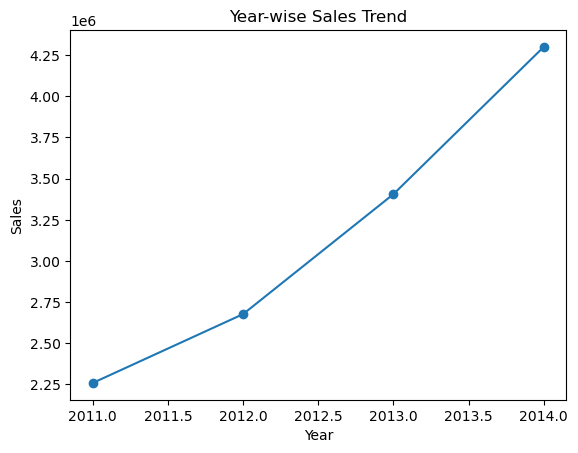

In [117]:
## Year-wise Sales trend
plt.plot( yearly_performance["year"],yearly_performance["total_sales"],marker="o")

plt.title("Year-wise Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

#### Insight:
Sales increased consistently from 2011 to 2014, indicating strong overall business growth.

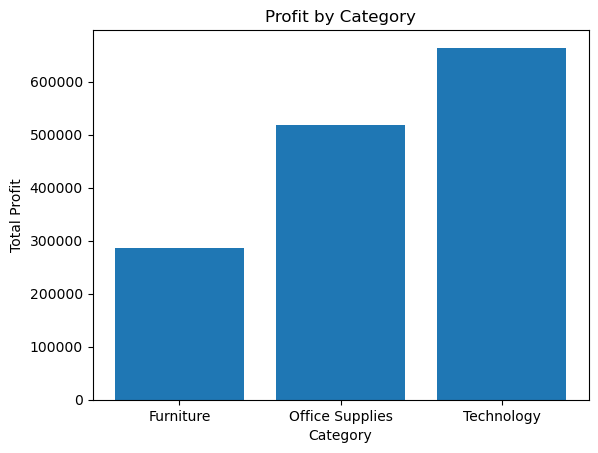

In [120]:
## Category-wise Profit
plt.bar(category_performance["category"],category_performance["total_profit"])

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.show()

#### Insight: 
Technology generated the highest profit, while Furniture had comparatively lower profitability.

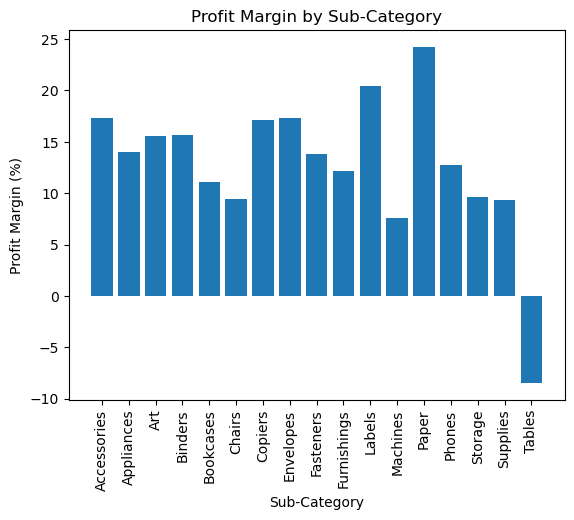

In [126]:
# Sub-category Profit Margin
plt.bar(sub_category_performance["sub_category"],sub_category_performance["profit_margin"])

plt.xticks(rotation=90)
plt.title("Profit Margin by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Profit Margin (%)")
plt.show()

#### Insight: 
Paper had the highest profit margin, while Tables showed a negative margin and require further investigation.

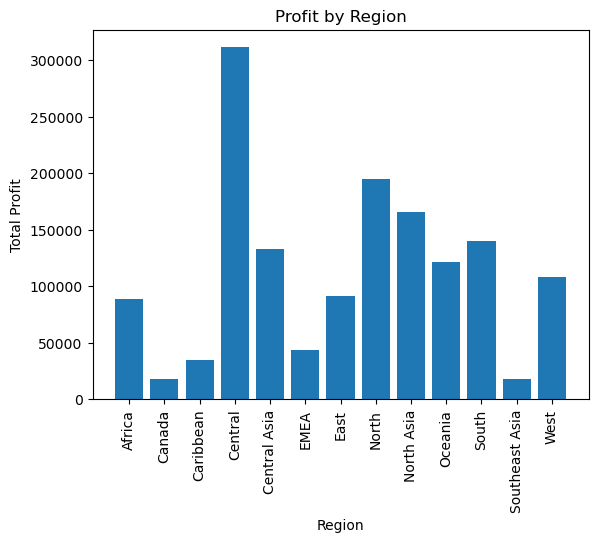

In [140]:
# Regional Profit

plt.bar(region_performance["region"],region_performance["total_profit"])

plt.xticks(rotation=90)
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.show()

#### Insight: 
Central generated the highest profit, while Southeast Asia had very low profitability despite generating substantial sales.

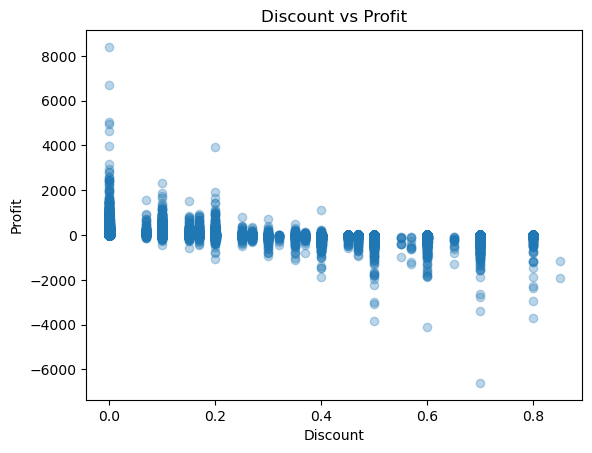

In [142]:
# Discount vs Profit
plt.scatter(data["discount"], data["profit"], alpha=0.3)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

#### Insight: 
Higher discount levels are associated with lower profitability, with 20%+ discount groups showing negative overall profit.